# 🧠 BurnoutRadar — An Intelligent Burnout Risk Classifier Based on Routine Patterns

The silent overload of modern work is becoming one of the greatest mental health challenges of our time. At the heart of the digital era—where productivity and hyperconnectivity collide—detecting early signs of burnout is no longer a luxury, but a necessity.

In this project, I developed a predictive model within the **health tech** domain that simulates early detection of burnout based on behavioral data such as sleep patterns, weekly workload, screen time, and level of social interaction. By transforming everyday signals into **analytical risk features**, we can anticipate critical situations before they escalate into real breakdowns.

I used a supervised **machine learning** approach with a strong focus on interpretability and real-world application. The goal is not only to classify individuals at high risk of burnout but also to **create a preventive alert framework** that could be integrated into corporate wellness apps or personal self-assessment platforms.

🔍 Highlights:
- Simulation of a dataset inspired by real behavioral data;
- **Feature engineering** strategies to translate habits into risk variables;
- Supervised models focused on class balance and interpretability;
- Potential applications in **mental health analytics**, predictive HR, and AI-powered self-care platforms.

> This project bridges data, health, and technology — a small glimpse into what the intersection of **Data Science** and **well-being** can achieve.

Next, we'll load and explore the data to begin building our burnout risk classifier.


In [1]:
# Main imports

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.svm import LinearSVC

In [2]:
df: pd.DataFrame = pd.read_csv('/content/Burnout_Dataset.csv')
df.sample(5, random_state=241)

,hours_worked_per_day,hours_sleep,hours_exercise_per_week,social_interactions_per_week,screen_time_per_day,has_meeting_overload,feels_purpose_at_work,work_on_weekends,stress_level,burnout_risk
687,8.250358,6.801739,0.000000,2.0,3.415675,1,0,0,3,0
44,6.042956,6.241059,0.855160,4.0,6.595113,0,1,1,1,0
173,9.682304,6.406110,2.803516,5.0,4.164950,0,1,0,2,0
209,NaN,9.124365,NaN,4.0,6.278562,0,1,1,2,0
377,9.366684,8.059857,NaN,2.0,3.974599,0,1,0,2,0


Data Quality Diagnostics

Next, we work through the general structure of the dataset with `.info()`, seeking to understand the data types, dimensions and the presence of missing values.

### Initial Structure Diagnostics
Let's inspect the data type, columns and count of non-null values.


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   hours_worked_per_day          822 non-null    float64
 1   hours_sleep                   801 non-null    float64
 2   hours_exercise_per_week       829 non-null    float64
 3   social_interactions_per_week  908 non-null    float64
 4   screen_time_per_day           908 non-null    float64
 5   has_meeting_overload          1000 non-null   int64  
 6   feels_purpose_at_work         1000 non-null   int64  
 7   work_on_weekends              1000 non-null   int64  
 8   stress_level                  1000 non-null   int64  
 9   burnout_risk                  1000 non-null   int64  
dtypes: float64(5), int64(5)
memory usage: 78.3 KB


### Missing Value Analysis
We visualize the amount of missing data in each variable to define our imputation strategy later on

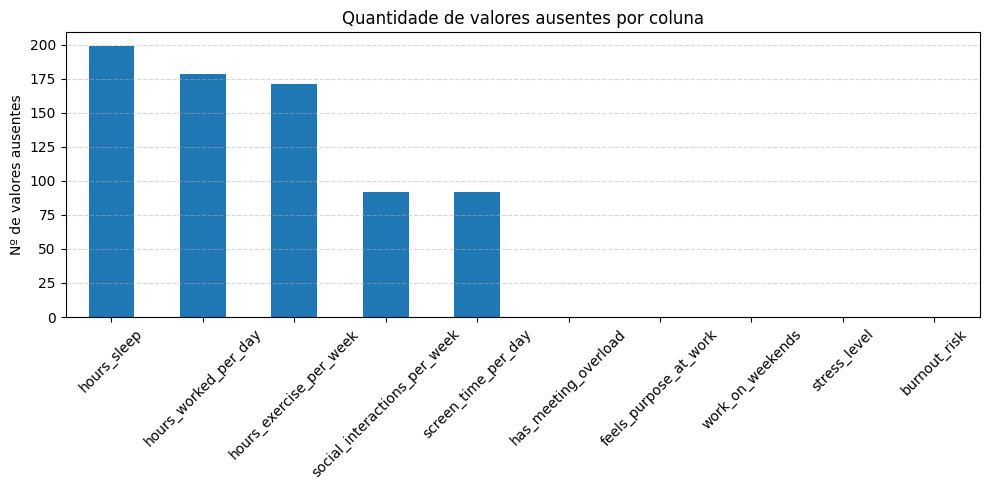

In [4]:
df.isna().sum().sort_values(ascending=False).plot(kind='bar', figsize=(10,5))
plt.title("Quantidade de valores ausentes por coluna")
plt.ylabel("Nº de valores ausentes")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Descriptive statistics
Here we analyze the mean, standard deviation, and quartiles of numerical variables to understand the scale and dispersion of each variable.

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
hours_worked_per_day,822.0,9.045311,1.932480,4.0,7.724696,9.050601,10.274848,14.0
hours_sleep,801.0,6.595105,1.458413,3.0,5.597949,6.565404,7.562163,10.0
hours_exercise_per_week,829.0,2.555940,1.806565,0.0,1.183767,2.395191,3.770836,10.0
social_interactions_per_week,908.0,2.972467,1.591845,0.0,2.000000,3.000000,4.000000,9.0
screen_time_per_day,908.0,6.997241,2.472201,3.0,5.112157,6.887838,8.787132,14.0
has_meeting_overload,1000.0,0.391000,0.488219,0.0,0.000000,0.000000,1.000000,1.0
feels_purpose_at_work,1000.0,0.594000,0.491330,0.0,0.000000,1.000000,1.000000,1.0
work_on_weekends,1000.0,0.320000,0.466710,0.0,0.000000,0.000000,1.000000,1.0
stress_level,1000.0,2.985000,1.433468,1.0,2.000000,3.000000,4.000000,5.0
burnout_risk,1000.0,0.076000,0.265131,0.0,0.000000,0.000000,0.000000,1.0


### Why visualize before imputing?

Before applying imputation techniques such as `mean()` or `median()`, it is essential to understand the **behavior of the data distribution**.

Some variables may present **asymmetric distributions** or contain **extreme outliers**. In these cases, the **mean may be distorted**, making the **median a more robust option**.

On the other hand, variables with a more symmetric distribution and without extreme values ​​can be well represented by the **mean**, maintaining consistency with the center of the distribution.

To make this decision based on evidence, we will:
- Visualize the distribution of variables with missing values ​​(`boxplot` and `histplot`);
- Apply the most appropriate strategy for each one;
- Visually verify the impact of the imputation.

This practice ensures careful and justified treatment — not only technical, but also interpretable.

Visualizing the distribution of variables with missing values ​​(before imputation)

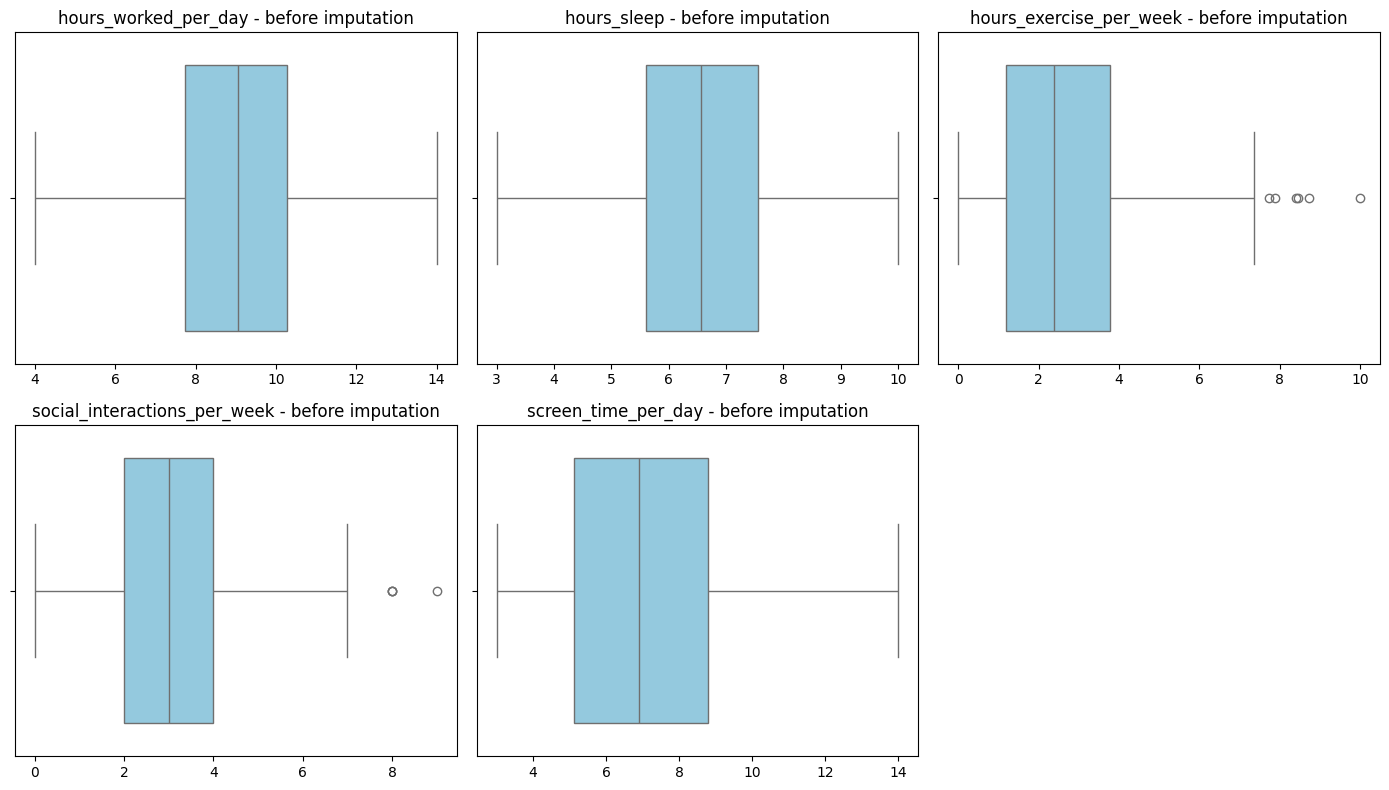

In [6]:
cols_missing = ['hours_worked_per_day', 'hours_sleep', 'hours_exercise_per_week',
'social_interactions_per_week', 'screen_time_per_day']


plt.figure(figsize=(14, 8))
for i, col in enumerate(cols_missing, 1):
  plt.subplot(2, 3, i)
  sns.boxplot(x=df[col], color='skyblue')
  plt.title(f"{col} - before imputation")
  plt.xlabel('')
plt.tight_layout()
plt.show()

# Conditional imputation: mean for symmetric distributions, median for variables with outliers

In [7]:
df_imputed = df.copy()

df_imputed['hours_sleep'].fillna(df['hours_sleep'].mean(), inplace=True)
df_imputed['hours_worked_per_day'].fillna(df['hours_worked_per_day'].mean(), inplace=True)
df_imputed['screen_time_per_day'].fillna(df['screen_time_per_day'].mean(), inplace=True)

df_imputed['hours_exercise_per_week'].fillna(df['hours_exercise_per_week'].median(), inplace=True)
df_imputed['social_interactions_per_week'].fillna(df['social_interactions_per_week'].median(), inplace=True)

<ipython-input-7-3fd8b8974072>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed['hours_sleep'].fillna(df['hours_sleep'].mean(), inplace=True)
<ipython-input-7-3fd8b8974072>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

Checking the impact of imputation on data

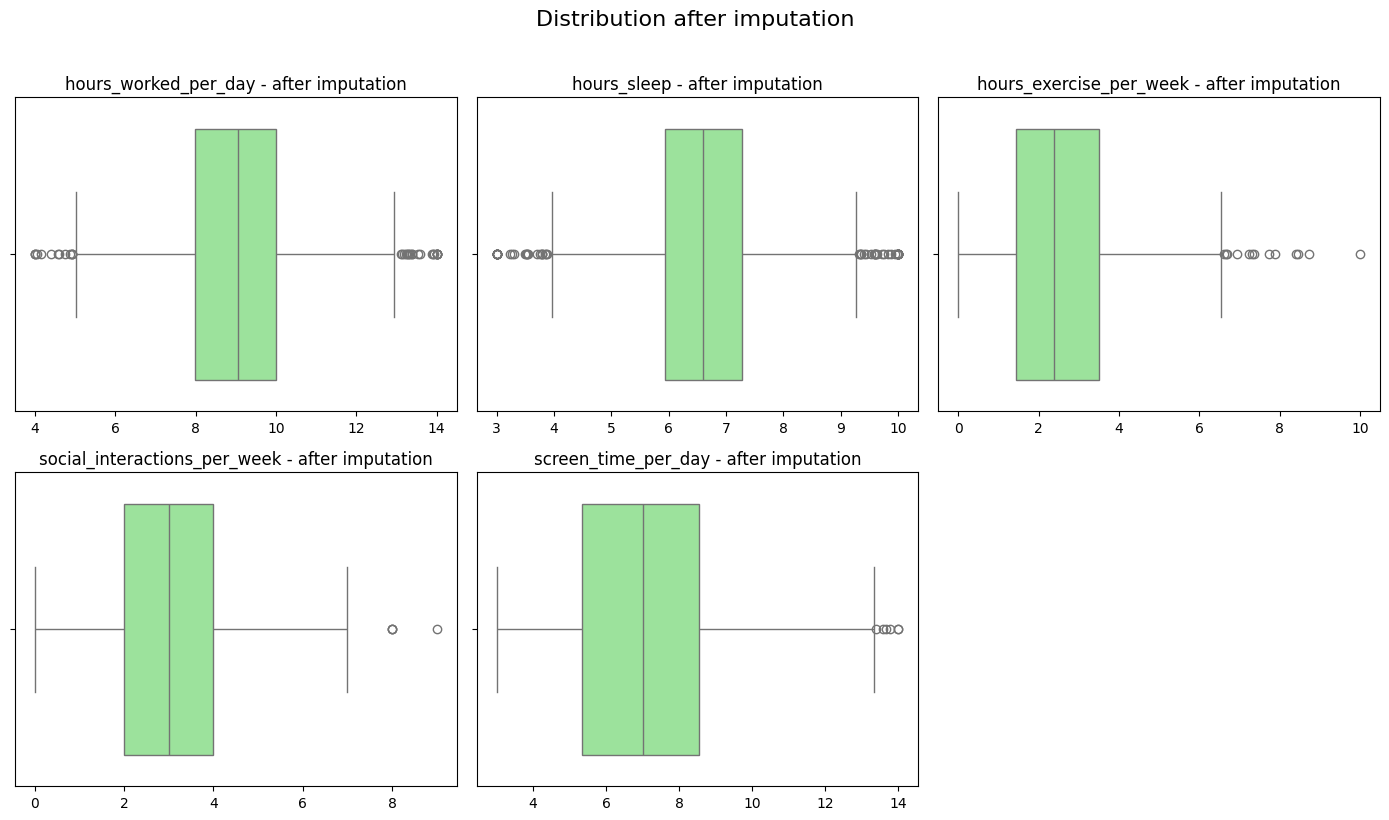

In [27]:
plt.figure(figsize=(14, 8))
plt.suptitle("Distribution after imputation", fontsize=16, y=1.02)

for i, col in enumerate(cols_missing, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df_imputed[col], color='lightgreen')
    plt.title(f"{col} - after imputation")
    plt.xlabel('')
plt.tight_layout()
plt.show()

### 🧠 Why do we have more outliers after imputation?

After applying the imputation techniques (mean or median), we visualize the boxplots again to analyze the new distribution of the data. An interesting — and expected — detail is that **some variables now have more visible outliers** than before.

🔍 This happens for a few statistical reasons:

1. **The concentration of central values ​​has increased**
By filling missing values ​​with `mean()` or `median()`, we add **many identical values ​​to the center of the distribution**. This **reduces the variability** of the sample and **shortens the “box” of the boxplot** (which represents the interquartile range, or IQR).

2. **Boundaries for defining outliers have become narrower**
As the IQR has shrunk, the range that defines what is “normal” has become tighter.

👉 Consequence: **values ​​that were previously within the limit now appear as outliers.**

3. **Visual ≠ real problem**

Even with more points being marked as outliers, the data is **more complete and usable**. Imputation helps the model to generalize better, as long as it is done in a justified way — as it was done here, based on the distribution analysis.

✅ Most importantly: **we document each step with visual evidence and technical criteria.** This strengthens the quality and explainability of the project.

# Confirming that all missing values ​​have been imputed

In [9]:
df_imputed.isna().sum().sort_values(ascending=False)

,0
hours_worked_per_day,0
hours_sleep,0
hours_exercise_per_week,0
social_interactions_per_week,0
screen_time_per_day,0
has_meeting_overload,0
feels_purpose_at_work,0
work_on_weekends,0
stress_level,0
burnout_risk,0


### Distribution of the target variable (`burnout_risk`)
We check whether the dataset is balanced or unbalanced — a factor that directly influences the performance of classification models.

<ipython-input-28-494d9c85daa8>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='burnout_risk', data=df_imputed, palette='Set2')


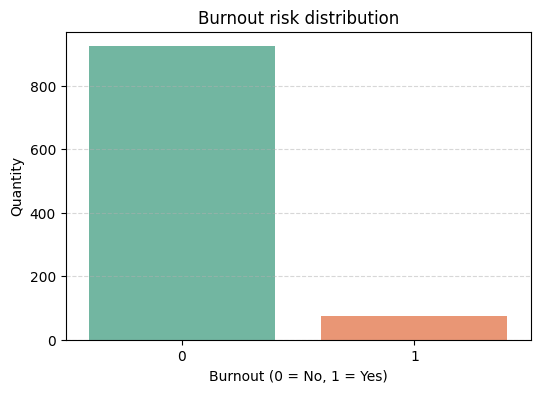

In [28]:
plt.figure(figsize=(6, 4))
sns.countplot(x='burnout_risk', data=df_imputed, palette='Set2')
plt.title("Burnout risk distribution")
plt.xlabel("Burnout (0 = No, 1 = Yes)")
plt.ylabel("Quantity")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Separating target variable (y) from predictors (x)

In [15]:
y = df_imputed['burnout_risk']
x = df_imputed.drop('burnout_risk', axis=1)

train_x, test_x, train_y, test_y = train_test_split(x, y, test_size=0.25, random_state=241, stratify=y)
print(f"We trained with {len(train_x)} elements")
print(f"We tested with {len(test_x)} elements")

In [16]:
model = LinearSVC()
model.fit(train_x, train_y)
predictions = model.predict(test_x)

hit_rate = accuracy_score(test_y, predictions)
print(f'Hit rate: {hit_rate*100:.2f}%')

We trained with 750 elements
We tested with 250 elements
Hit rate: 96.00%


# Full evaluation of the original model
# We will mainly look at the recall of class 1 (burnout cases)

In [17]:
print(classification_report(test_y, predictions, digits=4))

              precision    recall  f1-score   support

           0     0.9702    0.9870    0.9785       231
           1     0.8000    0.6316    0.7059        19

    accuracy                         0.9600       250
   macro avg     0.8851    0.8093    0.8422       250
weighted avg     0.9573    0.9600    0.9578       250



# Internally balanced model (class_weight='balanced')
# This approach adjusts class weights automatically

In [19]:
model_balanced = LinearSVC(class_weight='balanced', random_state=241)
model_balanced.fit(train_x, train_y)
predictions_bal = model_balanced.predict(test_x)

print(classification_report(test_y, predictions_bal, digits=4))


              precision    recall  f1-score   support

           0     0.9859    0.9091    0.9459       231
           1     0.4324    0.8421    0.5714        19

    accuracy                         0.9040       250
   macro avg     0.7092    0.8756    0.7587       250
weighted avg     0.9439    0.9040    0.9175       250



In [34]:
# 🧬 Strategy 2 — Balancing with SMOTE
# Generating synthetic examples of the minority class in the training set

smote = SMOTE(random_state=42)
train_x_resampled, train_y_resampled = smote.fit_resample(train_x, train_y)

print("Distribution after SMOTE:")
print(train_y_resampled.value_counts())


model_smote = LinearSVC(random_state=42)
model_smote.fit(train_x_resampled, train_y_resampled)
predictions_smote = model_smote.predict(test_x)

print("\n📊 Classification Report - Model with SMOTE")
print(classification_report(test_y, predictions_smote, digits=4))

Distribution after SMOTE:
burnout_risk
0    693
1    693
Name: count, dtype: int64

📊 Classification Report - Model with SMOTE
              precision    recall  f1-score   support

           0     0.9904    0.8961    0.9409       231
           1     0.4146    0.8947    0.5667        19

    accuracy                         0.8960       250
   macro avg     0.7025    0.8954    0.7538       250
weighted avg     0.9467    0.8960    0.9125       250



### Final Comparison — Models Evaluated

Below, the direct comparison between the tested strategies, focusing on recall of class 1 — the most critical for our use case.

In [36]:

results = pd.DataFrame({
    'Modelo': ['Original', 'Class Weight', 'SMOTE'],
    'Precision (Classe 1)': [0.80, 0.43, 0.41],
    'Recall (Classe 1)': [0.63, 0.84, 0.89],
    'F1-Score (Classe 1)': [0.71, 0.57, 0.56],
    'Acurácia Geral': [0.96, 0.904, 0.896]
})

results.set_index('Modelo', inplace=True)
display(results)


,Precision (Classe 1),Recall (Classe 1),F1-Score (Classe 1),Acurácia Geral
Modelo,,,,
Original,0.80,0.63,0.71,0.960
Class Weight,0.43,0.84,0.57,0.904
SMOTE,0.41,0.89,0.56,0.896


### 📌 Comparing Models and Choosing the Best Strategy

We trained three versions of our burnout risk classifier, each exploring a different approach to dealing with class imbalance — one of the biggest challenges in real-world classification problems.

🔍 **Summary of the evaluated models:**

- **Original Model:** Showed high overall accuracy (96%), but identified only 63% of burnout cases. In a mental health setting, this represents a high risk of underdiagnosis.

- **Class Weight (`balanced`):** Significantly improved recall (84%), demonstrating greater sensitivity to the minority class, but with a drop in precision.

- **SMOTE (Oversampling):** Achieved the best recall (89%) with still solid overall accuracy (~90%), offering the best balance between **sensitivity and practical applicability**.

---

📣 **Final decision:**
> We opted for the model with **SMOTE**, which has proven to be more effective in detecting burnout early, even at the cost of some false positives.
> In **preventive mental health screening** contexts, **erring too much is preferable to erring too little** — and the model delivers exactly that.

💡 This choice reinforces an essential principle in human applications of AI:
> **Predicting responsibly is as important as predicting accurately.**